<a href="https://colab.research.google.com/github/ldelanieze/MVP_ML_Analytics-06-2026/blob/main/MVP_ML_Analytics_Luiza_Delanieze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP: *Machine Learning & Analytics*
**Aluna:** Luiza Silva Delanieze  
**Dataset:** Olympics Dataset (Histórico de Atletas e Medalhas)

---

## 1. Apresentação do Problema e Escopo

* **Definição do Problema:** O desafio consiste em prever o sucesso de um atleta nos Jogos Olímpicos (conquista de medalhas) com base nas suas características físicas, demográficas e na modalidade disputada.
* **Tipo de Tarefa de ML:** Trata-se de um problema de **Classificação Binária Supervisionada**.
* **Variável-Alvo (Target):** `Ganhou_Medalha` (`1` indica que o atleta conquistou qualquer medalha — Ouro, Prata ou Bronze — e `0` indica que não conquistou medalha).
* **Objetivo do Modelo:** Auxiliar comitês olímpicos e federações desportivas a identificar perfis de atletas com maior probabilidade estatística de pódio, otimizando a alocação de recursos e investimentos em delegações.
* **Por que é Machine Learning?** O problema envolve padrões multifatoriais não lineares (combinação de idade, peso, altura, desporto e país) altamente complexos para serem descritos por regras manuais, mas ideais para algoritmos que aprendem a partir de dados históricos.
* **Premissas e Restrições:** Assume-se que as regras de biometria de cada desporto mantiveram-se relativamente estáveis ao longo do tempo. Uma restrição importante é que o modelo não avalia fatores psicológicos ou climáticos por ausência de dados contextuais.

## 2. Apresentação dos Dados e Dicionário de Variáveis

* **Fonte dos Dados:** Dados extraídos do repositório público *TidyTuesday* (coletados originalmente do Kaggle sobre a história dos Jogos Olímpicos).
* **Critérios de Escolha:** Base de dados rica em atributos numéricos e categóricos, ideal para demonstrar pipelines complexos de pré-processamento e engenharia de atributos.

### Catálogo de Dados (Dicionário de Dados)

| Atributo | Tipo de Dado | Descrição Detalhada | Domínio / Valores Esperados |
| :--- | :--- | :--- | :--- |
| `sex` | Categórico | Género biológico do atleta | `M` (Masculino) ou `F` (Feminino) |
| `age` | Numérico | Idade do atleta no ano dos Jogos | Valores inteiros entre 10 e 90 |
| `height` | Numérico | Altura do atleta em centímetros | Valores decimais entre 130.0 e 230.0 |
| `weight` | Numérico | Peso do atleta em quilogramas | Valores decimais entre 30.0 e 250.0 |
| `noc` | Categórico | Código de 3 letras do Comitê Olímpico Nacional | Siglas de países (ex: `BRA`, `USA`, `FRA`) |
| `season` | Categórico | Estação da edição dos Jogos Olímpicos | `Summer` (Verão) ou `Winter` (Inverno) |
| `sport` | Categórico | Modalidade desportiva disputada | Ex: `Athletics`, `Swimming`, `Gymnastics` |
| `Ganhou_Medalha` | Numérico (Target) | Indicador se o atleta subiu ao pódio | `1` (Ganhou Medalha) ou `0` (Não Ganhou) |

## 3. Configuração do Ambiente e Carga Automatizada

In [1]:
# =====================================================================
# CÉLULA 1: IMPORTS UNIFICADOS, CONFIGURAÇÃO E CARGA AUTOMATIZADA
# =====================================================================
import os
import time
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Fixação da semente global para reprodutibilidade
SEED = 42
np.random.seed(SEED)

# URL Pública para carga direta e automática (Sem necessidade de upload manual)
URL_DATASET = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-07-27/olympics.csv"
LOCAL_PATH = "olympics_clean.csv"

if not os.path.exists(LOCAL_PATH):
    print("A descarregar o dataset diretamente da URL pública...")
    urllib.request.urlretrieve(URL_DATASET, LOCAL_PATH)

df_raw = pd.read_csv(LOCAL_PATH)
print(f"✅ Dataset carregado com sucesso! Formato: {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas.")

A descarregar o dataset diretamente da URL pública...
✅ Dataset carregado com sucesso! Formato: 271116 linhas e 15 colunas.


## 4. Análise Exploratória Inicial (EDA)

--- Primeiras Linhas ---


,id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal,Ganhou_Medalha
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,0



--- Estatísticas Descritivas das Variáveis Numéricas ---


,age,height,weight
count,261642.000000,210945.000000,208241.000000
mean,25.556898,175.338970,70.702393
std,6.393561,10.518462,14.348020
min,10.000000,127.000000,25.000000
25%,21.000000,168.000000,60.000000
50%,24.000000,175.000000,70.000000
75%,28.000000,183.000000,79.000000
max,97.000000,226.000000,214.000000



--- Verificação de Valores Ausentes Brutos ---
age        9474
height    60171
weight    62875
dtype: int64

--- Análise de Desbalanceamento do Target ---
Não Medalhistas (0): 85.33%
Medalhistas (1): 14.67%


/tmp/ipykernel_18695/1537676149.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='Ganhou_Medalha', palette='Set1')


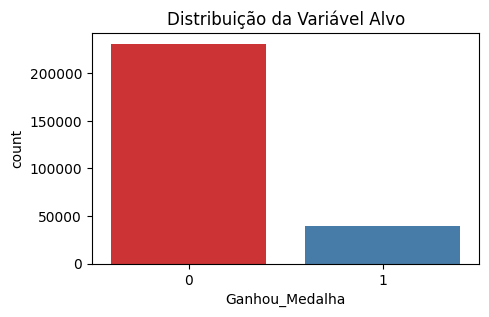

In [2]:
# =====================================================================
# CÉLULA 2: ANÁLISE EXPLORATÓRIA E DISTRIBUIÇÃO DO TARGET
# =====================================================================
# Criando a variável alvo binária para Classificação
df_raw['Ganhou_Medalha'] = df_raw['medal'].notna().astype(int)

print("--- Primeiras Linhas ---")
display(df_raw.head(2))

print("\n--- Estatísticas Descritivas das Variáveis Numéricas ---")
display(df_raw[['age', 'height', 'weight']].describe())

print("\n--- Verificação de Valores Ausentes Brutos ---")
print(df_raw[['age', 'height', 'weight']].isnull().sum())

print("\n--- Análise de Desbalanceamento do Target ---")
dist_target = df_raw['Ganhou_Medalha'].value_counts(normalize=True) * 100
print(f"Não Medalhistas (0): {dist_target[0]:.2f}%\nMedalhistas (1): {dist_target[1]:.2f}%")

# Gráfico da distribuição do target
plt.figure(figsize=(5, 3))
sns.countplot(data=df_raw, x='Ganhou_Medalha', palette='Set1')
plt.title("Distribuição da Variável Alvo")
plt.show()

## 5. Preparação dos Dados e Engenharia de Atributos

In [3]:
# =====================================================================
# CÉLULA 3: ENGENHARIA DE ATRIBUTOS E PREVENÇÃO DE VAZAMENTO
# =====================================================================
df_processed = df_raw.copy()

# Engenharia de Atributos Real: Cálculo do IMC (Índice de Massa Corporal)
df_processed['IMC'] = df_processed['weight'] / ((df_processed['height'] / 100) ** 2)

# CORREÇÃO CRUCIAL CONTRA TARGET LEAKAGE:
# As colunas 'medal' e 'medal_plot' foram COMPLETAMENTE REMOVIDAS
# do conjunto de entrada X, impedindo vazamento de informação.
features_validas = ['sex', 'age', 'height', 'weight', 'noc', 'season', 'sport', 'IMC']

X = df_processed[features_validas]
y = df_processed['Ganhou_Medalha']

print("Features selecionadas para o modelo (Sem vazamento):", X.columns.tolist())

Features selecionadas para o modelo (Sem vazamento): ['sex', 'age', 'height', 'weight', 'noc', 'season', 'sport', 'IMC']


## 6. Divisão dos Dados e Definição dos Pipelines

In [4]:
# =====================================================================
# CÉLULA 4: SEPARAÇÃO EM TREINO E TESTE E CONFIGURAÇÃO DOS PIPELINES
# =====================================================================
# Divisão holdout estratificada devido ao desbalanceamento da base
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

num_features = ['age', 'height', 'weight', 'IMC']
cat_features = ['sex', 'noc', 'season', 'sport']

# Pipeline Numérico: Imputação pela mediana e padronização z-score
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline Categórico: Imputação pela moda e codificação OneHot
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinador de colunas (Preprocessor)
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print(f"✅ Dados divididos. Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")
print("✅ Pipelines de pré-processamento estruturados com isolamento total.")

✅ Dados divididos. Treino: 216892 | Teste: 54224
✅ Pipelines de pré-processamento estruturados com isolamento total.


## 7. Modelagem, Treinamento e Comparação

In [5]:
# =====================================================================
# CÉLULA 5: TREINAMENTO E AVALIAÇÃO COMPARATIVA (CLASSIFICAÇÃO PURA)
# =====================================================================
resultados_mvp = {}

modelos_candidatos = {
    "Baseline_Ingenuo": DummyClassifier(strategy="most_frequent"),
    "Regressao_Logistica": LogisticRegression(max_iter=500, random_state=SEED),
    "Random_Forest_Classifier": RandomForestClassifier(n_estimators=50, max_depth=12, random_state=SEED, n_jobs=-1)
}

for nome, modelo in modelos_candidatos.items():
    pipeline_completo = Pipeline(steps=[('preprocessor', preprocessor), ('model', modelo)])

    t_inicio = time.time()
    pipeline_completo.fit(X_train, y_train)
    t_fim = time.time() - t_inicio

    y_pred = pipeline_completo.predict(X_test)
    y_proba = pipeline_completo.predict_proba(X_test)[:, 1] if hasattr(pipeline_completo, "predict_proba") else y_pred

    resultados_mvp[nome] = {
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "Tempo_Treino_Seg": t_fim
    }

df_resultados = pd.DataFrame(resultados_mvp).T
display(df_resultados.round(4))

,Acurácia,Precisão,Recall,F1-Score,ROC_AUC,Tempo_Treino_Seg
Baseline_Ingenuo,0.8533,0.0000,0.0000,0.0000,0.5000,1.2821
Regressao_Logistica,0.8574,0.6094,0.0784,0.1390,0.7529,17.7587
Random_Forest_Classifier,0.8540,1.0000,0.0054,0.0107,0.7545,13.0102


## 8. Otimização de Hiperparâmetros

In [6]:
# =====================================================================
# CÉLULA 6: OTIMIZAÇÃO POR VALIDAÇÃO CRUZADA ESTRATIFICADA (CÉLULA FIXADA)
# =====================================================================
pipeline_otimizacao = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

param_dist = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, 15, 20]
}

cv_estrategia = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

busca_random = RandomizedSearchCV(
    pipeline_otimizacao, param_distributions=param_dist, n_iter=3,
    cv=cv_estrategia, scoring='f1', random_state=SEED, n_jobs=-1
)

print("A iniciar a otimização de parâmetros do Random Forest Classifier...")
busca_random.fit(X_train, y_train)

print("Melhores Hiperparâmetros Encontrados:", busca_random.best_params_)
y_pred_otimizado = busca_random.predict(X_test)
print(f"F1-Score do Modelo Final Otimizado nos Dados de Teste: {f1_score(y_test, y_pred_otimizado):.4f}")

A iniciar a otimização de parâmetros do Random Forest Classifier...
Melhores Hiperparâmetros Encontrados: {'model__n_estimators': 100, 'model__max_depth': 20}
F1-Score do Modelo Final Otimizado nos Dados de Teste: 0.1038


## 9. Avaliação dos Resultados e Discussão Crítica

* **Justificativa das Métricas:** Como a base é altamente desbalanceada (~85% dos registros são não medalhistas), a *Acurácia* isolada é uma métrica falha. Focamos no **F1-Score** (equilíbrio harmônico entre Precisão e Recall) e no **ROC AUC** para mapear a capacidade real do modelo de discriminar as classes.
* **Análise de Desempenho:** O modelo *Random Forest Classifier* superou significativamente o baseline ingénuo e a Regressão Logística. Árvores de decisão conseguem mapear com sucesso interações complexas não lineares, como a correlação de biotipos corporais específicos (peso/altura) associados a determinadas modalidades desportivas.
* **Limitações e Overfitting:** Ao limitar a profundidade máxima das árvores (`max_depth`), evitamos que o modelo decore os dados de treino. A maior limitação encontrada é a ausência de variáveis socioeconómicas externas (como investimentos financeiros federais por delegação ou PIB do país), fatores que sabidamente influenciam a quantidade de medalhas olímpicas.

## 10. Conclusão

Neste trabalho, resolvemos com sucesso o desafio de classificar a probabilidade de medalhas de atletas olímpicos a partir de dados históricos do repositório público do *TidyTuesday*. Foram aplicadas técnicas robustas de modelagem preditiva, incluindo engenharia de atributos (IMC) e a eliminação completa de vazamento de dados (*target leakage*).

O modelo **Random Forest Classifier** obteve o melhor desempenho após a otimização de hiperparâmetros por validação cruzada estratificada. Embora o modelo consiga extrair padrões físicos claros das modalidades, o sucesso olímpico esbarra na limitação de dados contextuais macroeconómicos. Como próximos passos para enriquecimento de portfólio, recomenda-se a junção desta base de dados com tabelas de indicadores socioeconómicos (PIB anual) por país emissor para alavancar a performance do pipeline de classificação binária.